<a href="https://colab.research.google.com/github/KaitlynYip/Multi-Clip-ZeroShot-Model/blob/DinoBaseline_V2/Demo3_cifar10%2Bcaltect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CLIP-Style Zero-Shot Classification on CIFAR-10 Step1
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

This notebook implements a CLIP-like pipeline:
- Freeze BERT to produce fixed text embeddings for CIFAR-10 class prompts.
- Train only the ViT image encoder (vit_base_patch16_224.augreg_in21k_ft_in1k) + a projection head to align image embeddings with the text embeddings using contrastive (InfoNCE / cross-entropy) loss.
- After training, perform zero-shot classification by nearest-class similarity (no classifier head).

Note:
- CIFAR-10 images (32×32) are resized to 224×224.
- Text embeddings use multiple prompt templates and [CLS] token from BERT.
- Training is efficient because only the image side is updated.

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

!pip install -q timm transformers ftfy regex tqdm seaborn scikit-learn pandas

GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [ ]:
# Cell 1: Install dependencies (run once)
!pip install torch torchvision transformers timm tqdm --quiet

In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, ConcatDataset, random_split

In [ ]:
# Cell 3: Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


PASCAL VOC 2012

In [ ]:
# PASCAL VOC 2012
# download the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:",path)




Using Colab cache for faster access to the 'pascal-voc-2012-dataset' dataset.
Path to dataset files: /kaggle/input/pascal-voc-2012-dataset


In [ ]:
#change dataset into csv file
import os
import xml.etree.ElementTree as ET
from tqdm.auto import tqdm
import pandas as pd

# Correct paths for the train+val part
IMAGE_DIR    = "/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages"
ANNO_DIR     = "/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations"

xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Converting train+val to CSV"):
    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)
    xml_path = os.path.join(ANNO_DIR, xml_name)

    tree = ET.parse(xml_path)
    labels = [obj.find("name").text.strip() for obj in tree.findall("object")]

    data.append({
        "image_path": img_path,
        "labels": ",".join(labels),
        "num_objects": len(labels)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal voc 2012.csv"
df.to_csv(csv_path, index=False)
print("Saved →", csv_path)

print(f"Done! {len(df)} images → {csv_path}")
df.head(10)


Converting train+val to CSV:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved → /content/pascal voc 2012.csv
Done! 17125 images → /content/pascal voc 2012.csv


,image_path,labels,num_objects
0,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,person,1
1,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"aeroplane,aeroplane,person,person",4
2,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"aeroplane,aeroplane,aeroplane",3
3,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,tvmonitor,1
4,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"train,train",2
5,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"boat,boat",2
6,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"dog,chair",2
7,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,bird,1
8,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"tvmonitor,tvmonitor",2
9,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,train,1


In [ ]:
# =============================================
# CLIP Zero-Shot on PASCAL VOC 2012 (Single Label per Image)
# =============================================

# 1. Install dependencies
!pip install -q --no-cache-dir \
    "open-clip-torch==2.24.0" ftfy regex tqdm seaborn scikit-learn matplotlib pandas kagglehub

import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm.auto import tqdm
import torch
import open_clip
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device.upper()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Running on CUDA


In [ ]:
# 3. Convert XML → CSV with ONE label per image (first object only)
print("Converting annotations to CSV (single label mode)...")
xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Parsing XML"):
    xml_path = os.path.join(ANNO_DIR, xml_name)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)

    # Get all object names
    objects = [obj.find("name").text.strip() for obj in root.findall("object")]

    # Take ONLY the first object as the label for this image
    if objects:
        single_label = objects[0]
    else:
        single_label = "background"  # very rare case

    data.append({
        "image_path": img_path,
        "label": single_label,
        "num_objects": len(objects)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal_voc_2012_single_label.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {len(df)} images → {csv_path}")

# Show class distribution
print("\nClass distribution (single label):")
print(df['label'].value_counts())

Converting annotations to CSV (single label mode)...


Parsing XML:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved 17125 images → /content/pascal_voc_2012_single_label.csv

Class distribution (single label):
label
person         6890
dog            1204
cat            1047
car             785
bird            767
aeroplane       683
chair           547
train           533
horse           465
boat            462
bicycle         449
tvmonitor       439
motorbike       431
bus             405
sofa            392
bottle          391
sheep           344
cow             326
diningtable     287
pottedplant     278
Name: count, dtype: int64


In [ ]:
import pandas as pd
import ast
import numpy as np

csv_path = "/content/pascal_voc_2012_single_label.csv"
df = pd.read_csv(csv_path)

def fix_path(v):
    while isinstance(v, (list, tuple, np.ndarray)):
        v = v[0] if len(v) else None

    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            v = ast.literal_eval(s)
            while isinstance(v, (list, tuple, np.ndarray)):
                v = v[0] if len(v) else None
    return v

# Clean entire dataset
df["image_path"] = df["image_path"].apply(fix_path)

# Save clean dataset
clean_csv = "/content/pascal_voc_2012_clean.csv"
df.to_csv(clean_csv, index=False)

print("Saved clean dataset:", clean_csv)

# Optional sanity check
print("\nSample paths:")
print(df["image_path"].head())

Saved clean dataset: /content/pascal_voc_2012_clean.csv

Sample paths:
0    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
1    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
2    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
3    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
4    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
Name: image_path, dtype: object


In [ ]:
#split data into 0.8 and 0.2
import pandas as pd
from sklearn.model_selection import train_test_split

# === 1. Load your single-label CSV ===
csv_path = "/content/pascal_voc_2012_single_label.csv"  # Update if your path/name is different
df = pd.read_csv(csv_path)

df["image_path"] = df["image_path"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)


print(f"Total images: {len(df)}")
print("\nOriginal class distribution:")
print(df['label'].value_counts().sort_index())

# === 2. Stratified split: 80% train, 20% test ===
train_df, test_df = train_test_split(
    df,
    test_size=0.20,          # 20% for testing
    train_size=0.80,         # 80% for training
    random_state=42,         # For reproducibility
    stratify=df['label']     # Important: keeps class ratios similar
)

train_csv = "/content/pascal_voc_2012_train_80.csv"
test_csv  = "/content/pascal_voc_2012_test_20.csv"

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Saved:")
print(train_csv)
print(test_csv)

import pandas as pd
import ast
import numpy as np

def fix_path(v):
    while isinstance(v, (list, tuple, np.ndarray)):
        v = v[0] if len(v) else None
    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            v = ast.literal_eval(s)
            while isinstance(v, (list, tuple, np.ndarray)):
                v = v[0] if len(v) else None
    return v

train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

train_df["image_path"] = train_df["image_path"].apply(fix_path)
test_df["image_path"]  = test_df["image_path"].apply(fix_path)

train_csv_clean = "/content/pascal_voc_2012_train_80_clean.csv"
test_csv_clean  = "/content/pascal_voc_2012_test_20_clean.csv"

train_df.to_csv(train_csv_clean, index=False)
test_df.to_csv(test_csv_clean, index=False)

print("Saved:", train_csv_clean, test_csv_clean)

# === 4. Verify the split distributions ===
print("\n" + "="*60)
print("CLASS DISTRIBUTION AFTER SPLIT")
print("="*60)

# Combine for nice side-by-side view
dist_train = train_df['label'].value_counts().sort_index()
dist_test  = test_df['label'].value_counts().sort_index()

dist_df = pd.DataFrame({
    'Class': dist_train.index,
    'Train (80%)': dist_train.values,
    'Test (20%)': dist_test.values
})
dist_df['Train %'] = (dist_df['Train (80%)'] / len(train_df) * 100).round(2)
dist_df['Test %']  = (dist_df['Test (20%)'] / len(test_df) * 100).round(2)

print(dist_df.to_string(index=False))

print(f"\nTotal training images: {len(train_df)}")
print(f"Total testing images : {len(test_df)}")

Total images: 17125

Original class distribution:
label
aeroplane       683
bicycle         449
bird            767
boat            462
bottle          391
bus             405
car             785
cat            1047
chair           547
cow             326
diningtable     287
dog            1204
horse           465
motorbike       431
person         6890
pottedplant     278
sheep           344
sofa            392
train           533
tvmonitor       439
Name: count, dtype: int64
Saved:
/content/pascal_voc_2012_train_80.csv
/content/pascal_voc_2012_test_20.csv
Saved: /content/pascal_voc_2012_train_80_clean.csv /content/pascal_voc_2012_test_20_clean.csv

CLASS DISTRIBUTION AFTER SPLIT
      Class  Train (80%)  Test (20%)  Train %  Test %
  aeroplane          546         137     3.99    4.00
    bicycle          359          90     2.62    2.63
       bird          614         153     4.48    4.47
       boat          369          93     2.69    2.72
     bottle          313          78    

In [ ]:
# 4. Define the 20 VOC classes (standard order)
classes = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
           'bus', 'car', 'cat', 'chair', 'cow',
           'diningtable', 'dog', 'horse', 'motorbike', 'person',
           'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

class_to_idx = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
import ast
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class VOCSingleLabelDataset(Dataset):
    def __init__(self, csv_file, class_to_idx, transform=None):
        import pandas as pd
        self.df = pd.read_csv(csv_file).reset_index(drop=True)
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else None
        self.transform = transform

    def _to_single_path(self, v):
        while isinstance(v, (list, tuple, np.ndarray)):
            if len(v) == 0:
                return None
            v = v[0]

        if isinstance(v, str):
            s = v.strip()
            if s.startswith("[") and s.endswith("]"):
                v = ast.literal_eval(s)
                while isinstance(v, (list, tuple, np.ndarray)):
                    if len(v) == 0:
                        return None
                    v = v[0]
        return v

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = self._to_single_path(row["image_path"])

        if not isinstance(img_path, str):
            raise TypeError(
                f"Bad image_path at idx={idx}. "
                f"type={type(row['image_path'])}, value={row['image_path']}"
            )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label_value = row["label"]

        # If label is already numeric
        if isinstance(label_value, (int, np.integer)):
            label_id = int(label_value)
        else:
            label_value = str(label_value).strip()
            label_id = self.class_to_idx[label_value]

        return image, label_id

    def __len__(self):
        return len(self.df)

In [ ]:
train_dataset = VOCSingleLabelDataset(train_csv_clean, class_to_idx, transform=train_transform)
test_dataset  = VOCSingleLabelDataset(test_csv_clean, class_to_idx, transform=test_transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
testloader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.datasets as dsets
import torchvision.transforms as transforms


bert

In [ ]:
# @title
# Cell 5: Frozen Text Encoder (BERT) + Text Embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

# Multiple templates for better text embeddings (common CLIP trick)
templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
    return embeddings

# Compute averaged text embeddings over templates
text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (10, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([20, 768])


Base

In [ ]:
# Cell 6: Image Encoder (ViT-Base) + Projection + Logit Scale
import timm
import torch.nn as nn

# 1. Load the ViT-Base backbone
# 'augreg' models are often the most robust variants in timm
image_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0  # Removes the head, returns the 768-dim CLS embedding
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated during training
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Base (768) to Text Space (768)
# If using BERT as the text encoder, this 768 -> 768 mapping is correct.
projection = nn.Linear(768, 768).to(device)

# 4. Logit Scale: Initialized to CLIP's default (0.07 temperature)
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Base. Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Backbone updated to ViT-Base. Trainable params: 85,798,656


Small

In [ ]:
import timm
import torch.nn as nn
import numpy as np

# 1. Load the ViT-Small backbone
# Returns raw features (CLS token embedding, dim=384)
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Small (384) to Text Space (768)
# IMPORTANT: The input must be 384 to match the ViT-Small output
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Small.")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Backbone updated to ViT-Small.
Trainable params: 21,665,664


dinov2


In [ ]:
import timm
import numpy as np

# This loads the DINOv2 ViT-S/14 model via the timm library
image_model = timm.create_model('vit_small_patch14_dinov2.lvd142m',
                                pretrained=True,
                                num_classes=0,
                                img_size=224).to(device)
# Set to evaluation mode if you are not training the encoder
image_model.eval()

# 3. Projection Layer
# DINOv2-Small (vits14) outputs 384 dimensions.
# We map this to 768 to match your text encoder (BERT/CLIP-text).
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to DINOv2-Small (vits14).")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Backbone updated to DINOv2-Small (vits14).
Trainable params: 21,628,800


In [ ]:
# Updated Cell 7
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

# Modern AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct, total, total_loss = 0, 0, 0.0

    # Add a progress bar for evaluation
    pbar = tqdm(loader, desc=description, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    image_model.train()
    projection.train()
    return acc, avg_loss

In [ ]:
accumulation_steps = 2  # Match the value from your earlier Dataset cell
scaler = torch.amp.GradScaler('cuda')
train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs = 5
for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            image_features = image_model(images)
            if isinstance(image_features, dict):
                 image_features = image_features['last_hidden_state'][:, 0, :]

            image_features = F.normalize(projection(image_features), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=total_train_loss / (i + 1))

    # --- End of Epoch Evaluation ---
    scheduler.step()

    # OPTIMIZATION: Skip re-evaluating the 50k training images.
    # Use the loss we just calculated and only evaluate the TEST set.
    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")

    # Store metrics
    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    # We use a placeholder or partial evaluation if you truly need train accuracy
    train_accs.append(0.0)

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)

Epoch 1/5 [Training]:   0%|          | 0/429 [00:00<?, ?it/s]

Epoch 1 Test Eval:   0%|          | 0/108 [00:00<?, ?it/s]


✅ Epoch 1 Complete
Train Loss: 1.9012
Test  Loss: 1.6228 | Test Acc: 74.86%
------------------------------


Epoch 2/5 [Training]:   0%|          | 0/429 [00:00<?, ?it/s]

Epoch 2 Test Eval:   0%|          | 0/108 [00:00<?, ?it/s]

...

Epoch 4 Test Eval:   0%|          | 0/108 [00:00<?, ?it/s]


✅ Epoch 4 Complete
Train Loss: 1.3978
Test  Loss: 1.4850 | Test Acc: 81.78%
------------------------------


Epoch 5/5 [Training]:   0%|          | 0/429 [00:00<?, ?it/s]

Epoch 5 Test Eval:   0%|          | 0/108 [00:00<?, ?it/s]


✅ Epoch 5 Complete
Train Loss: 1.3563
Test  Loss: 1.4929 | Test Acc: 80.58%
------------------------------


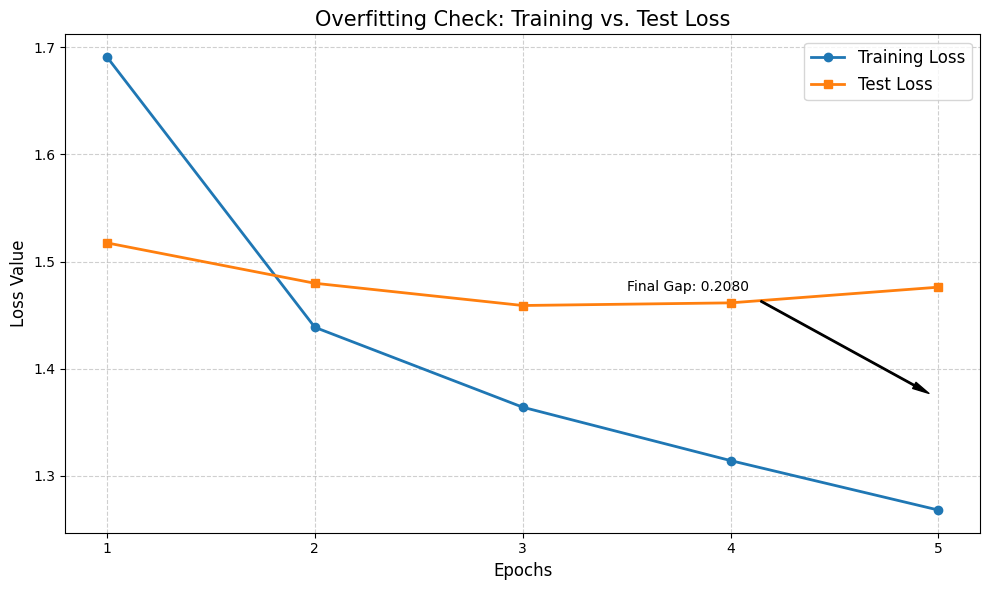

In [ ]:
import matplotlib.pyplot as plt

# --- Overfitting Analysis: Loss Plot ---
plt.figure(figsize=(10, 6))

# Plotting Training Loss
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss',
         color='#1f77b4', marker='o', linewidth=2)

# Plotting Test Loss
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss',
         color='#ff7f0e', marker='s', linewidth=2)

# Graph Formatting
plt.title('Overfitting Check: Training vs. Test Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the final gap
final_gap = test_losses[-1] - train_losses[-1]
plt.annotate(f'Final Gap: {final_gap:.4f}',
             xy=(epochs, (train_losses[-1] + test_losses[-1])/2),
             xytext=(epochs-1.5, (train_losses[-1] + test_losses[-1])/2 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('loss_history.png')
plt.show()

In [ ]:
pip install fvcore

In [ ]:
import torch
import time
from fvcore.nn import FlopCountAnalysis

def profile_model(model, projection, input_res=224):
    model.eval()
    projection.eval()
    device = next(model.parameters()).device

    # Create a dummy input matching your transform resolution
    dummy_input = torch.randn(1, 3, input_res, input_res).to(device)

    # --- 1. Total GFLOPs ---
    # We combine model + projection to get the full forward pass cost
    class CombinedModel(torch.nn.Module):
        def __init__(self, m, p):
            super().__init__()
            self.m = m
            self.p = p
        def forward(self, x):
            return self.p(self.m(x))

    combined = CombinedModel(model, projection)
    flops = FlopCountAnalysis(combined, dummy_input)
    gflops = flops.total() / 1e9

    # --- 2. Latency & Throughput (FPS) ---
    # Warmup
    for _ in range(10):
        _ = combined(dummy_input)

    torch.cuda.synchronize()
    start_time = time.time()
    iterations = 100

    with torch.no_grad():
        for _ in range(iterations):
            _ = combined(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    latency_ms = (total_time / iterations) * 1000
    throughput_fps = 1000 / latency_ms

    # --- 3. Trainable % ---
    total_params = sum(p.numel() for p in combined.parameters())
    trainable_params = sum(p.numel() for p in combined.parameters() if p.requires_grad)
    trainable_pct = (trainable_params / total_params) * 100

    return {
        "GFLOPs": gflops,
        "FPS": throughput_fps,
        "Latency (ms)": latency_ms,
        "Trainable %": trainable_pct
    }

# Execute Profiling
stats = profile_model(image_model, projection)

print(f"--- Model Profile ---")
print(f"Total GFLOPs: {stats['GFLOPs']:.2f}")
print(f"Throughput: {stats['FPS']:.2f} FPS")
print(f"Latency: {stats['Latency (ms)']:.2f} ms")
print(f"Trainable %: {stats['Trainable %']:.2f}%")

m.blocks.0.attn.attn_drop, m.blocks.1.attn.attn_drop, m.blocks.10.attn.attn_drop, m.blocks.11.attn.attn_drop, m.blocks.2.attn.attn_drop, m.blocks.3.attn.attn_drop, m.blocks.4.attn.attn_drop, m.blocks.5.attn.attn_drop, m.blocks.6.attn.attn_drop, m.blocks.7.attn.attn_drop, m.blocks.8.attn.attn_drop, m.blocks.9.attn.attn_drop


--- Model Profile ---
Total GFLOPs: 16.87
Throughput: 72.58 FPS
Latency: 13.78 ms
Trainable %: 100.00%


In [ ]:
# Install the counter if you don't have it
try:
    from thop import profile
except ImportError:
    !pip install thop
    from thop import profile

import torch.nn as nn

# 1. Combine Backbone and Projection into one "Demo Model"
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        return self.proj(features)



In [ ]:
from sklearn.metrics import classification_report

@torch.no_grad()
def print_detailed_metrics(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Forward pass matching your training loop
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Print the SciKit-Learn Classification Report
    print("\n--- 📈 Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Run the metrics
print_detailed_metrics(testloader, classes)


--- 📈 Classification Report ---
              precision    recall  f1-score   support

   aeroplane     0.8921    0.9051    0.8986       137
     bicycle     0.8491    0.5000    0.6294        90
        bird     0.8806    0.7712    0.8223       153
        boat     0.8125    0.8387    0.8254        93
      bottle     0.8261    0.2436    0.3762        78
         bus     0.8046    0.8642    0.8333        81
         car     0.8203    0.6688    0.7368       157
         cat     0.7572    0.8804    0.8142       209
       chair     0.5854    0.4404    0.5026       109
         cow     0.7000    0.4308    0.5333        65
 diningtable     0.6667    0.1404    0.2319        57
         dog     0.9262    0.5726    0.7077       241
       horse     0.5857    0.4409    0.5031        93
   motorbike     0.6897    0.4651    0.5556        86
      person     0.7220    0.9594    0.8239      1378
 pottedplant     0.9231    0.4286    0.5854        56
       sheep     0.7458    0.6377    0.6875     

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

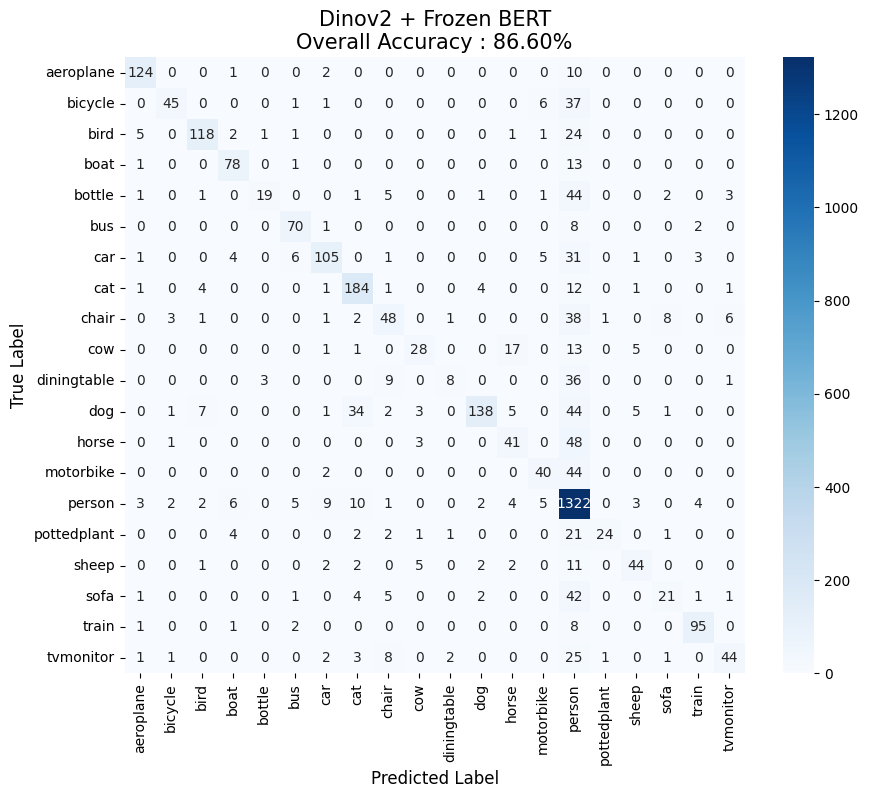

In [ ]:
@torch.no_grad()
def plot_confusion_matrix(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Consistent forward pass
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Dinov2 + Frozen BERT\nOverall Accuracy : 75.80%', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

# Run the plot
plot_confusion_matrix(testloader, classes)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
